# 확률과 확률분포

## 확률

- 확률(probability)
    - 어떤 사건(event)이 일어날 가능성
    - 예. 
        - 동전 던지기에서 앞면이 나올 가능성
        - 주사위 던지기에서 특정 눈금이 나올 확률
        - 주식투자에서 이득을 볼 가능성
        
        

- 의사결정
    - 확실성(certainty) 보다는 불확실한 상황에서 이루어지는 경우가 많음
    - 미래에 대한 불확실성의 정도가 더욱 심하다고 할 수 있음 
    - 불확실성 하에서 의사결정의 오류를 줄이기 위해 확률에 대한 연구 필요

### 확률의 기본

- 표본공간과 표본점
- 사상(사건)
- 확률의 정의
    - 객관적 확률(고전적/경험적확률)
    - 주관적 확률
    - 공리적 확률  
- 합사건 / 곱사건
- 상호배반
- 종속사건과 독립사건
- 결합확률 / 주변확률
- 조건부 확률
- 분할
- 전확률의 정리
- 베이즈 정리

## 확률변수와 확률분포

### 확률변수(random variable)
- 실험이나 관찰의 결과 값을 1:1 실수로 대응시키는 함수
- 일정한 확률로 나타나는(발생하는) 사건에 대해 숫자를 부여한 변수

#### 확률변수 구분
- 이산 확률변수(discrete random variable) : 변수가 취할 수 있는 값의 개수가 유한 
- 연속 확률변수(continuous random variable) : 변수가 취할 수 있는 값의 개수가 무한

### 확률분포(probability distribution)

- 확률변수가 취할 수 있는 모든 값에 대해 각각의 확률을 대응시킨 것

#### 확률분포 구분
- 확률질량함수(probability mass function: pmf) : 확률변수가 이산형인 경우
- 확률밀도함수(probability density function: pdf) : 확률변수가 연속형인 경우

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(f'numpy: {np.__version__}, pandas: {pd.__version__}')

numpy: 2.5.3, pandas: 3.0.5


In [2]:
%precision 3

'%.3f'

#### 1) 공정한 주사위의 확률분포를 구하는 실험

In [3]:
dice = [1,2,3,4,5,6]
prob = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

In [4]:
n_trial = 100
sample = np.random.choice(dice, size=n_trial, p=prob)
print(sample)
freq, bins = np.histogram(sample, bins=6, range=(1,7))
print(freq, bins)
dice_df = pd.DataFrame({'Freq':freq, 'Rel_Freq':freq/n_trial},
                      index=pd.Index(np.arange(1,7), name='dice'))
dice_df

[6 6 3 2 1 1 6 1 2 4 2 4 4 4 1 4 1 2 3 5 4 2 5 4 5 2 4 1 3 2 1 3 1 5 2 6 1
 3 3 2 2 1 2 3 3 1 5 3 5 1 3 1 3 4 5 5 1 4 4 2 3 2 6 6 4 6 4 4 2 2 2 3 4 1
 4 3 1 1 2 6 5 4 5 5 4 1 6 2 5 6 1 6 2 2 1 6 4 6 2 3]
[20 21 15 19 12 13] [1. 2. 3. 4. 5. 6. 7.]


,Freq,Rel_Freq
dice,,
1,20,0.20
2,21,0.21
3,15,0.15
4,19,0.19
5,12,0.12
6,13,0.13


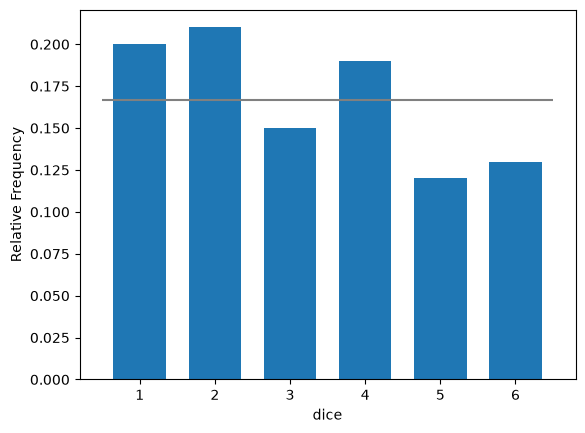

In [5]:
plt.hist(sample, bins=6, range=(1,7), density=True, rwidth=0.7)
plt.xticks(np.linspace(1.5, 6.5, 6), [f'{x}' for x in range(1,7)])
plt.hlines(prob, np.arange(1,7), np.arange(2,8), color='gray')
plt.xlabel('dice')
plt.ylabel('Relative Frequency')
plt.show()

In [6]:
def draw_dice_hist(num_trial, prob):
    dice = [1,2,3,4,5,6]
    sample = np.random.choice(dice, size=num_trial, p=prob)
    plt.figure(figsize=(6,4))
    plt.hist(sample, bins=6, range=(1,7), density=True, rwidth=0.7)
    plt.xlabel('dice')
    plt.ylabel('Relative Frequency')
    plt.xticks(np.linspace(1.5, 6.5, 6), [f'{x}' for x in range(1,7)])
    plt.hlines(prob, np.arange(1,7), np.arange(2,8), color='gray')
    plt.show()

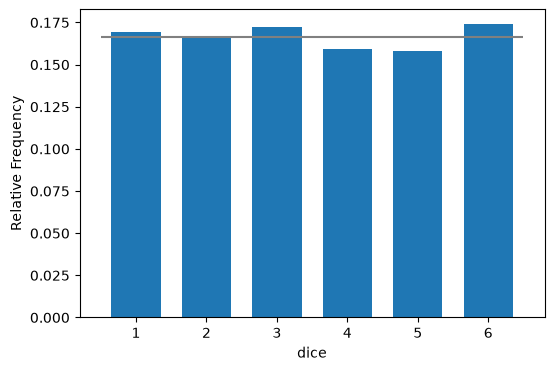

In [9]:
draw_dice_hist(num_trial=2000, prob=[1/6]*6)

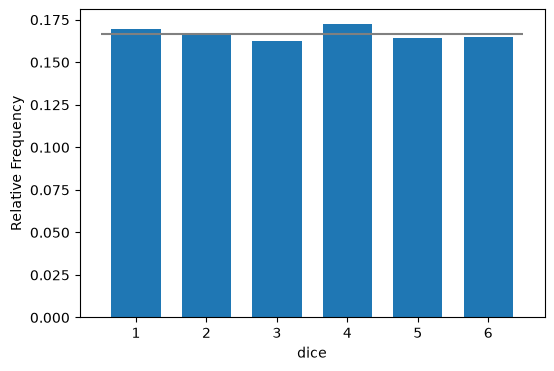

In [10]:
draw_dice_hist(num_trial=10000, prob=[1/6]*6)

#### 10000번 시도 : 실제 확률분포에 가까워짐

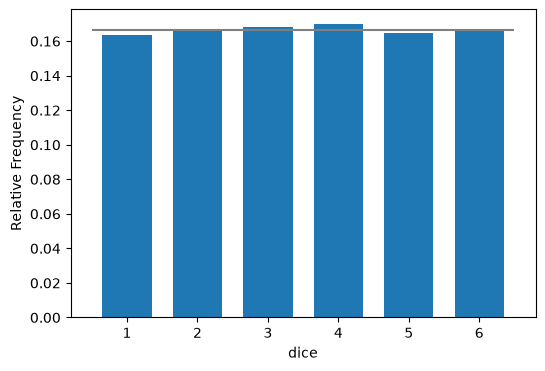

In [11]:
draw_dice_hist(num_trial=50000, prob=[1/6]*6)

- 모평균

In [12]:
mu = 0
for x, p in zip(dice, prob):
    mu += x*p
mu

3.500

In [13]:
np.sum([x*p for x, p in zip(dice, prob)])

3.500

In [14]:
np.dot(dice, prob)

3.500

- 표본평균

In [15]:
dice_df

,Freq,Rel_Freq
dice,,
1,20,0.20
2,21,0.21
3,15,0.15
4,19,0.19
5,12,0.12
6,13,0.13


In [16]:
np.sum(dice_df.index  * dice_df.Rel_Freq)

3.210

#### 2) 불공정한 주사위의 확률분포를 구하는 실험

In [18]:
prob = [ x/21 for x in range(1,7)]
prob

[0.048, 0.095, 0.143, 0.190, 0.238, 0.286]

In [19]:
def make_dice_df(n_trial, prob):
    dice = [1,2,3,4,5,6]
    sample = np.random.choice(dice, size=n_trial, p=prob)
    freq, bins = np.histogram(sample, bins=6, range=(1,7))
    dice_df = pd.DataFrame({'Freq':freq, 'Rel_Freq':freq/n_trial},
                           index=pd.Index(np.arange(1,7), name='dice'))
    return dice_df

In [20]:
make_dice_df(5000, prob)

,Freq,Rel_Freq
dice,,
1,248,0.0496
2,501,0.1002
3,719,0.1438
4,939,0.1878
5,1155,0.2310
6,1438,0.2876


In [21]:
make_dice_df(10000, prob)

,Freq,Rel_Freq
dice,,
1,455,0.0455
2,979,0.0979
3,1482,0.1482
4,1925,0.1925
5,2329,0.2329
6,2830,0.2830


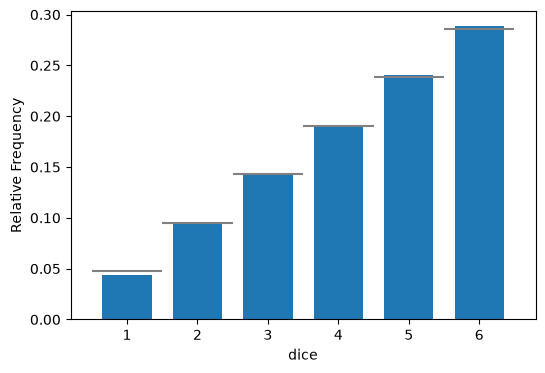

In [22]:
draw_dice_hist(5000,prob)

#### 10000번 시도 : 실제 확률분포에 가까워짐

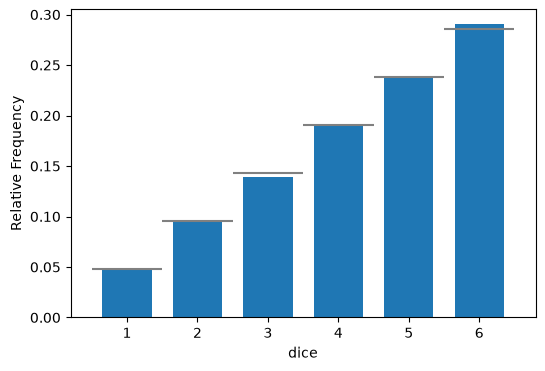

In [24]:
draw_dice_hist(num_trial=10000,prob=prob)

- 모평균(기대값)

In [25]:
np.dot(dice,prob)

4.333

In [34]:
dice_df = pd.DataFrame(zip(dice, prob), columns=['Freq','Rel_Freq'])
dice_df

,Freq,Rel_Freq
0,1,0.047619
1,2,0.095238
2,3,0.142857
3,4,0.190476
4,5,0.238095
5,6,0.285714


- 표본평균

In [38]:
np.dot(dice_df['Freq'], dice_df['Rel_Freq'])

4.333

## 확률분포의 평균(mean)과 분산(variance)

####  확률분포의 평균(mean)

- 기대값(expected value)
    -  확률 변수의 기대값(${E}$)은 각 사건이 벌어졌을 때의 이득과 그 사건이 벌어질 확률을 곱한 것을 전체 사건에 대해 합한 값 

- 어떤 확률적 사건에 대한 평균의 의미
- ${E(X)}$ 또는 ${μ_X }$ 로 표시
- 이산확률분포의 기대값 : 확률을 가중값으로 사용한 가중평균
- 연속확률분포의 기대값 : 적분개념의 면적
    
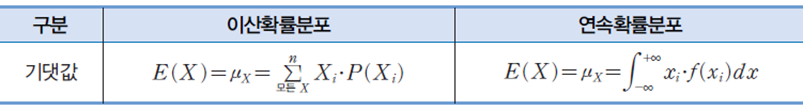


- 모평균(population mean) : ${ μ}$
    - 모집단의 평균

In [30]:
x_set = np.array([1,2,3,4,5,6])
# 확률질량함수(pmf)
def f(x):
    if x in x_set:
        return 1/6
    else:
        return 0

In [31]:
f(1), f(10)

(0.167, 0)

In [32]:
list(map(f, x_set))

[0.167, 0.167, 0.167, 0.167, 0.167, 0.167]

#### 기대값 함수

In [36]:
def E(X):
    x_set, f = X
    return np.sum([xi*f(xi) for xi in x_set])

In [37]:
def E2(X, g=lambda x:2*x +3):
    x_set, f = X
    return np.sum([g(xi)*f(xi) for xi in x_set])

In [43]:
X = [x_set, f]

#### 확률분포의 분산(variance)

- ${Var(X)}$  표시
- 확률변수의 평균(기대값)으로부터의 편차의 제곱에 대한 기대값으로 계산

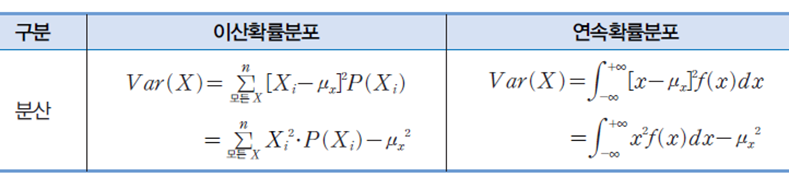


In [41]:
def V(X):
    x_set, f = X
    mu = E(X)
    return np.sum([(xi-mu)**2 * f(xi) for xi in x_set])

In [44]:
X

[array([1, 2, 3, 4, 5, 6]), <function __main__.f(x)>]

In [45]:
V(X)

2.917

In [46]:
# V(X) = E(X^2) - (E(X))^2
np.dot(dice, dice)/6 - np.dot(dice, prob)**2

-3.611

In [49]:
x_set

array([1, 2, 3, 4, 5, 6])

In [50]:
# 불공정한 주사위에 대한 확률분포
def f2(x):
    if x in x_set:
        return x/21
    else:
        return 0

In [51]:
f2(6)

0.286

In [53]:
# 불공정한 주사위에 대한 확률분포에서 확률변수의 기대값
X2 = [x_set, f2]
E(X2)

4.333

In [54]:
# 불공정한 주사위에 대한 확률분포에서 확률변수의 분산
V(X2)

2.222

------

In [55]:
import scipy
scipy.__version__

'1.18.0'

- https://scipy.org/
- https://docs.scipy.org/doc/scipy/reference/index.html
- https://docs.scipy.org/doc/scipy/reference/stats.html

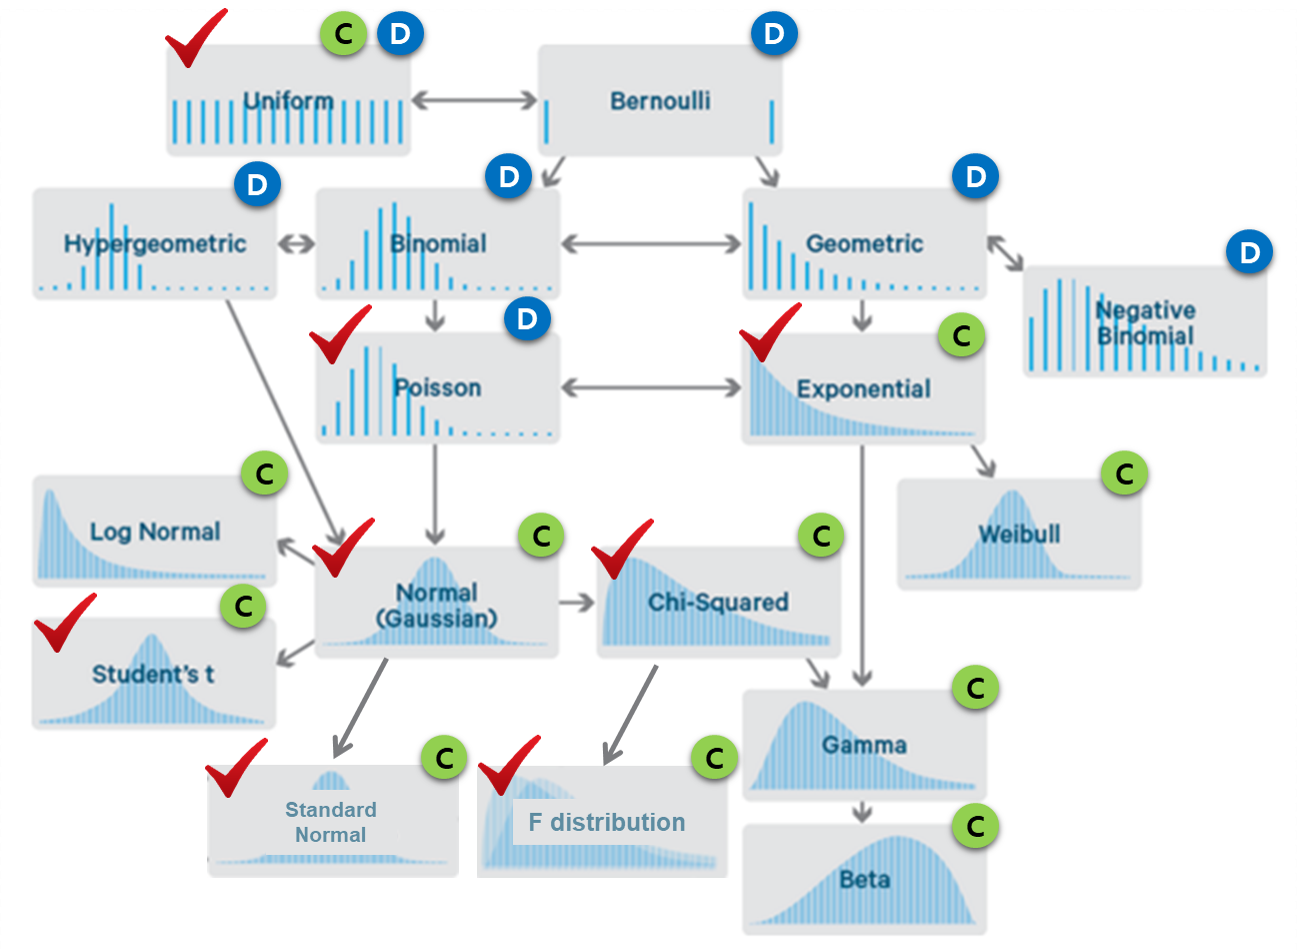

출처: https://www.datasciencecentral.com/profiles/blogs/common-probability-distributions-the-data-scientist-s-crib-sheet

In [56]:
from scipy import stats

## 이산형 확률분포

- 베르누이 분포
- 이항분포
- 포아송분포
- 기하분포

### 이항분포(binomial distribution)

- $ X $ ~ $ B(n,p) $

In [57]:
import math
math.comb(10,2)

45

In [58]:
# X ~B(10, 0.5)

n, p = 10, 0.5
[math.comb(n, x)*p**x*(1-p)**(n-x) for x in range(n+1)]

[0.001, 0.010, 0.044, 0.117, 0.205, 0.246, 0.205, 0.117, 0.044, 0.010, 0.001]

In [60]:
def binom_pmf(n,p):
    return {x:math.comb(n, x)*p**x*(1-p)**(n-x) for x in range(n+1)}

In [61]:
binom_pmf(n,p)

{0: 0.001,
 1: 0.010,
 2: 0.044,
 3: 0.117,
 4: 0.205,
 5: 0.246,
 6: 0.205,
 7: 0.117,
 8: 0.044,
 9: 0.010,
 10: 0.001}

In [62]:
df = pd.DataFrame(pd.Series(binom_pmf(n,p)), columns=['P(X)'])
df.index.name = 'X'
df

,P(X)
X,
0,0.000977
1,0.009766
2,0.043945
3,0.117188
4,0.205078
5,0.246094
6,0.205078
7,0.117188
8,0.043945


In [63]:
def draw_binom_pmf(n, p):
    px = binom_pmf(n, p)
    pmf = pd.DataFrame.from_dict(px, orient='index', columns=['P(X)'])
    plt.figure(figsize=(6,4))
    plt.bar(pmf.index, pmf['P(X)'])
    plt.title(f'X~B(n={n}, p={p})')
    plt.xlabel('X')
    plt.ylabel('P(X)')
    plt.show()
    return pmf

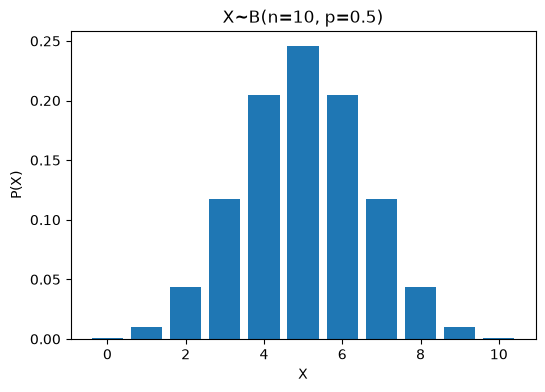

,P(X)
0,0.000977
1,0.009766
2,0.043945
3,0.117188
4,0.205078
5,0.246094
6,0.205078
7,0.117188
8,0.043945
9,0.009766


In [66]:
draw_binom_pmf(n=10, p=0.5)

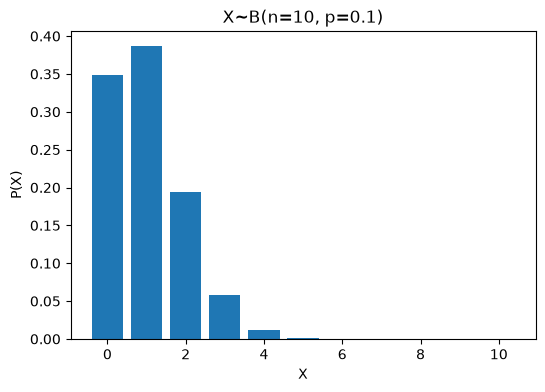

,P(X)
0,3.486784e-01
1,3.874205e-01
2,1.937102e-01
3,5.739563e-02
4,1.116026e-02
5,1.488035e-03
6,1.377810e-04
7,8.748000e-06
8,3.645000e-07
9,9.000000e-09


In [68]:
draw_binom_pmf(n=10, p=0.1)

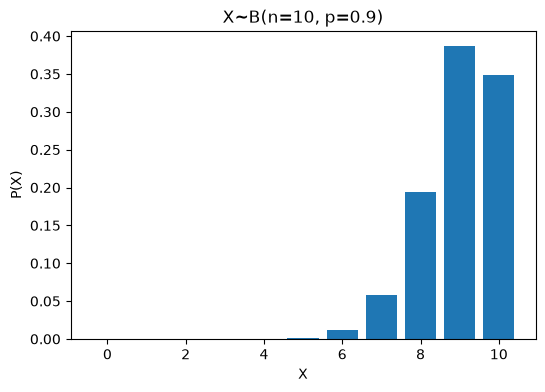

,P(X)
0,1.000000e-10
1,9.000000e-09
2,3.645000e-07
3,8.748000e-06
4,1.377810e-04
5,1.488035e-03
6,1.116026e-02
7,5.739563e-02
8,1.937102e-01
9,3.874205e-01


In [69]:
draw_binom_pmf(n=10, p=0.9)

#### 이항분포의 기댓값과 분산
- 기댓값(E(X)) = 시행횟수(n) * 성공확률(p)
- 분산(V(x)) = 시행횟수(n) * 성공확률(p) * 실패확률(1-p)

In [70]:
n, p = 10, 0.5
Ex = n*p
Vx = n*p*(1-p)
print(f'X~B(n={n}, p={p})의 E(X)={Ex}, V(X)={Vx}')

X~B(n=10, p=0.5)의 E(X)=5.0, V(X)=2.5


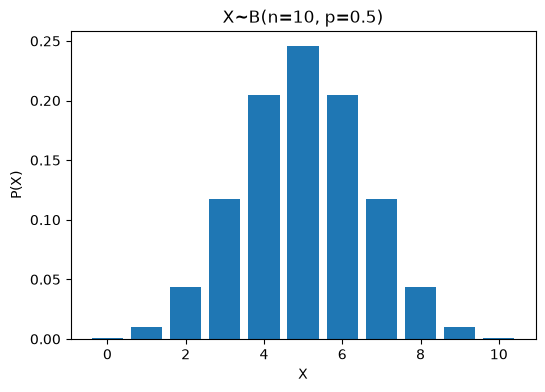

,P(X)
0,0.000977
1,0.009766
2,0.043945
3,0.117188
4,0.205078
5,0.246094
6,0.205078
7,0.117188
8,0.043945
9,0.009766


In [72]:
pmf = draw_binom_pmf(n=10, p=0.5)
pmf

In [73]:
# 기댓값
Ex2 = np.dot(pmf.index, pmf['P(X)'])
# 분산 = E(x^2) - E(x)^2
Vx2 = np.dot(pmf.index**2, pmf['P(X)']**2)

In [76]:
### Scipy.stats의 binom() 이용
from scipy import stats
n,p = 10, 0.5
rv = stats.binom(n,p)
rv.pmf(0), rv.pmf(6)

(0.001, 0.205)

In [80]:
rv.pmf(np.arange(n+1))

array([0.001, 0.01 , 0.044, 0.117, 0.205, 0.246, 0.205, 0.117, 0.044,
       0.01 , 0.001])

In [78]:
# scipy의 stats.binom() 사용
def draw_binom_pmf2(n, p):
    rv = stats.binom(n, p)
    x_set = np.arange(n+1)
    px = rv.pmf(x_set)
    plt.figure(figsize=(6,4))
    plt.bar(x_set, px)
    plt.title(f'X~B(n={n}, p={p})')
    plt.xlabel('X')
    plt.ylabel('P(X)')
    plt.show()
    pmf = pd.Series(px, name='P(X)')
    return pmf

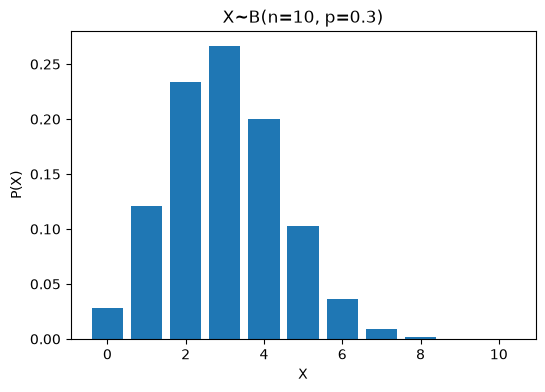

0     0.028248
1     0.121061
2     0.233474
3     0.266828
4     0.200121
5     0.102919
6     0.036757
7     0.009002
8     0.001447
9     0.000138
10    0.000006
Name: P(X), dtype: float64

In [79]:
draw_binom_pmf2(10, 0.3)

In [81]:
n,p = 10, 0.5
rv = stats.binom(n, p)
m, v, s, k =rv.stats(moments='mvsk')  #'m':mean, 'v':variance, 's':skewness, 'k':kurtosis
print(f'mean:{m}, variance:{v}, skewness:{s}, kurtosis:{k:.3f}')

mean:5.0, variance:2.5, skewness:0.0, kurtosis:-0.200


In [82]:
rv = stats.binom(n=10, p=0.5)
print(f'mean:{rv.mean():.3f}, var:{rv.var():.3f}, median:{rv.median():.3f}')

mean:5.000, var:2.500, median:5.000


## 연속형 확률분포

- 정규분포
- t분포
- 카이제곱분포
- F분포

#### numpy로 연속형 확률분포에 성질 확인을 위한 함수들 정의

### 정규분포

$ X $ ~ $ N( \mu , \sigma^2 ) $ 

#### numpy로 정규분포함수 정의

#### scipy.stats의 norm() 함수

### 지수분포

#### numpy로 지수분포함수 정의

#### scipy.stats의 expon() 함수

-----